   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ag_news_train_balanced.parquet:   0%|          | 0.00/651k [00:00<?, ?B/s]

ag_news_train_imbalanced.parquet:   0%|          | 0.00/313k [00:00<?, ?B/s]

ag_news_test_small.parquet:   0%|          | 0.00/650k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5900 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4000 [00:00<?, ? examples/s]

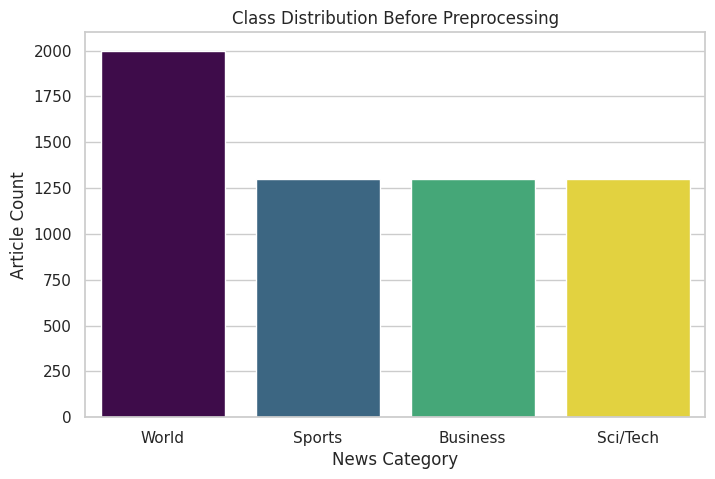

In [1]:
# Setup and Load Data
!pip install transformers datasets matplotlib seaborn pandas scikit-learn gradio evaluate -q

import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid")
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

dataset = load_dataset("SUBHANmm/Smaller_AG_News_Dataset")
if "test" not in dataset:
    dataset = dataset["train"].train_test_split(test_size=0.15, seed=42)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

# Visualize Original Data
plt.figure(figsize=(8, 5))
labels = train_dataset['label']
sns.countplot(x=labels, palette="viridis", hue=labels, legend=False)
plt.title("Class Distribution Before Preprocessing")
plt.xlabel("News Category")
plt.ylabel("Article Count")
plt.xticks(ticks=[0, 1, 2, 3], labels=class_names)
plt.show()

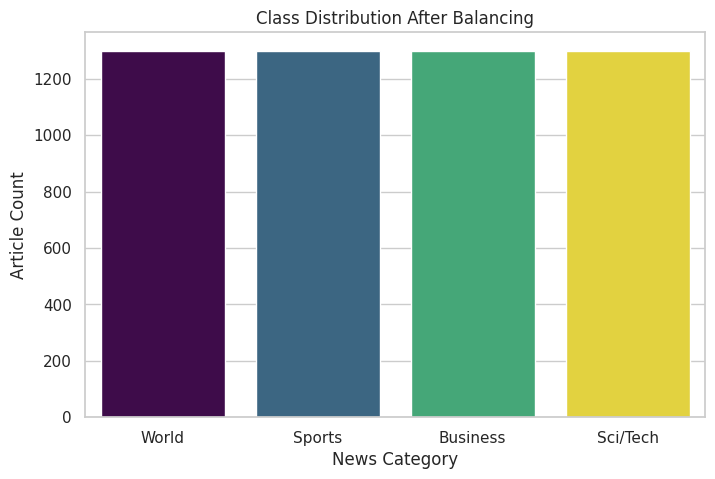

In [2]:
# Balance the Dataset
import pandas as pd
from datasets import Dataset

df_train = train_dataset.to_pandas()
min_class_count = df_train['label'].value_counts().min()
df_balanced = df_train.groupby('label').sample(n=min_class_count, random_state=42)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
train_dataset = Dataset.from_pandas(df_balanced)

# Visualize Balanced Data
plt.figure(figsize=(8, 5))
labels = train_dataset['label']
sns.countplot(x=labels, palette="viridis", hue=labels, legend=False)
plt.title("Class Distribution After Balancing")
plt.xlabel("News Category")
plt.ylabel("Article Count")
plt.xticks(ticks=[0, 1, 2, 3], labels=class_names)
plt.show()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5200 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

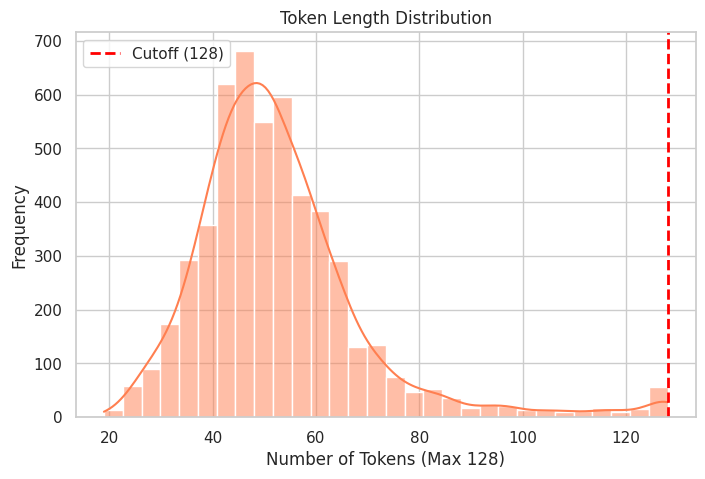

In [3]:
# Tokenize and Clean Data
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Visualize Token Lengths
attention_masks = tokenized_train['attention_mask']
token_lengths = [sum(mask) for mask in attention_masks]

plt.figure(figsize=(8, 5))
sns.histplot(token_lengths, bins=30, kde=True, color="coral")
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens (Max 128)")
plt.ylabel("Frequency")
plt.axvline(x=128, color='red', linestyle='--', linewidth=2, label='Cutoff (128)')
plt.legend()
plt.show()

# Clean Dataset Columns
columns_to_remove = ["text", "__index_level_0__"] if "__index_level_0__" in tokenized_train.column_names else ["text"]
tokenized_train = tokenized_train.remove_columns(columns_to_remove)
tokenized_test = tokenized_test.remove_columns(columns_to_remove)

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

In [4]:
# Configure and Train Model
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./ag_news_bert_pro",
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()
trainer.save_model("./final_ag_news_model")
tokenizer.save_pretrained("./final_ag_news_model")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy,F1
50,1.063803,0.610781,0.867750,0.866683
100,0.428414,0.331204,0.899750,0.899330
150,0.395072,0.303586,0.903750,0.903833
200,0.276358,0.291188,0.906250,0.906338
250,0.294230,0.288877,0.908750,0.909031
300,0.293795,0.305474,0.902250,0.903034
350,0.203500,0.288704,0.912000,0.911818
400,0.163285,0.286560,0.909500,0.909361
450,0.161259,0.288299,0.916500,0.916482
500,0.157693,0.306267,0.910750,0.910723


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_ag_news_model/tokenizer_config.json',
 './final_ag_news_model/tokenizer.json')

In [7]:
# Mount Drive and Copy Model
from google.colab import drive
import shutil

drive.mount('/content/drive')

# Copies the model folder directly to your main Drive
shutil.copytree('./final_ag_news_model', '/content/drive/MyDrive/AG_News_BERT_Model')
print("Model successfully saved to Google Drive!")

Mounted at /content/drive
Model successfully saved to Google Drive!


Final Accuracy: 0.9090
Final F1-Score: 0.9089


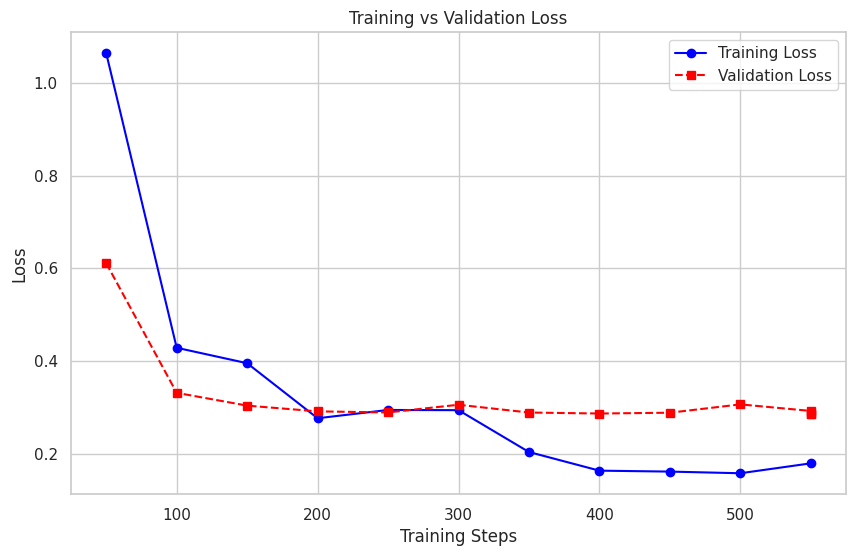

In [6]:
# Evaluate and Plot Metrics
import matplotlib.pyplot as plt

# Extract final metrics
eval_results = trainer.evaluate()
print(f"Final Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Final F1-Score: {eval_results['eval_f1']:.4f}")

# Plot loss curve
log_history = trainer.state.log_history
train_steps = [log['step'] for log in log_history if 'loss' in log]
train_losses = [log['loss'] for log in log_history if 'loss' in log]
eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
eval_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, marker='o', color='blue', label='Training Loss')
plt.plot(eval_steps, eval_losses, marker='s', linestyle='--', color='red', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
# Deploy Interactive Web App
import gradio as gr
from transformers import pipeline

classifier = pipeline("text-classification", model="./final_ag_news_model", tokenizer="./final_ag_news_model")
label_mapping = {"LABEL_0": "World", "LABEL_1": "Sports", "LABEL_2": "Business", "LABEL_3": "Sci/Tech"}

def classify_news(text):
    result = classifier(text)[0]
    label = label_mapping.get(result['label'], "Unknown Category")
    return f"Prediction: {label} (Confidence: {result['score']:.2f})"

demo = gr.Interface(
    fn=classify_news,
    inputs=gr.Textbox(lines=5, placeholder="Enter a news headline here..."),
    outputs="text",
    title="News Topic Classifier",
    description="Classify news text into World, Sports, Business, or Sci/Tech."
)

demo.launch(share=True, debug=False)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://788e0c809eb913c4c9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
